# Identify structures

Delineate individual **TLS structures** from the `zone_consol` labels assigned in [06_label_zones.ipynb](06_label_zones.ipynb). For each sample, the TLS-zone cells are enclosed by an **alpha shape** (concave hull) to outline discrete structures, which are then filtered by area, smoothed, and characterized by shape metrics (area, perimeter, circularity, minor/major axes). Each cell is finally assigned a TLS structure id (plus area and centroid) via a point-in-polygon spatial join, and the structure polygons and per-cell indices are saved back to the AnnData object for the downstream distance analyses.

**Pinned Environment:** [`conda_envs/space2_20250604.yml`](../conda_envs/space2_20250604.yml)

In [7]:
from pathlib import Path
import sys
import os
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata
import scanpy as sc
import squidpy as sq

import pickle
import joblib

from shapely.geometry import MultiPolygon
from alphashape import alphashape
import geopandas as gpd

import random

In [8]:
warnings.simplefilter(action='ignore', category=Warning)

## Local file info


In [9]:
sys.path.append(str(Path.cwd().resolve().parents[0]))

from config.paths import BASE_OUTDIR, INPUTS_DIR, FUNCTIONS_DIR

inputs_dir = INPUTS_DIR
merged_labels_dir = os.path.join(BASE_OUTDIR, "merge_labels")
out_dir = os.path.join(BASE_OUTDIR, "structures")
plot_out_dir = os.path.join(out_dir, 'plots')

if not os.path.exists(out_dir):
    os.makedirs(out_dir)
if not os.path.exists(plot_out_dir):
    os.makedirs(plot_out_dir)

print(out_dir)

/home/workspace/spatial_mouse_lung_outputs/structures


In [10]:
import importlib
if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.append(str(FUNCTIONS_DIR))

# import plotting functions as pu
import plotting_utils as pu

## Load adata

In [11]:
# adata saved in 06_label_zones.ipynb
adata = sc.read_h5ad(os.path.join(merged_labels_dir,'adata_labeled_zones.h5ad'))

## Load cell type and zone palettes

In [12]:
with open(os.path.join(inputs_dir, 'palettes/20250519_celltype_palette_mapped.pkl'), 'rb') as f:
    celltype_palette_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250520_celltype_palette_coarse_mapped.pkl'), 'rb') as f:
    celltype_palette_coarse_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250520_celltype_palette_coarser_mapped.pkl'), 'rb') as f:
    celltype_palette_coarser_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250521_zone_consol_palette_mapped.pkl'), 'rb') as f:
    zone_consol_palette_mapped = pickle.load(f)

## Structure identification 

### Functions to generate structure mask using alphashapes

In [13]:
def get_alphashape(adata, zone_column, zone_id, alpha):
    """
    Computes and plots the alpha shape (concave hull) around spatial coordinates of selected zones.

    Returns:
        shapely.MultiPolygon: Alpha shape geometry of the selected cells.
    """
    
    # get alphashape masks
    adata.obs['highlight'] = adata.obs[zone_column].isin(zone_id)
    mask = adata.obs['highlight']
    spatial_coords = adata.obsm['spatial'][mask, :]
    alpha_shape = alphashape(spatial_coords, alpha=alpha)

    # plot initial masks and borders
    fig, ax = plt.subplots(1,1, figsize=(8,6))
    ax.scatter(spatial_coords[:, 0], spatial_coords[:, 1], s=0.1, color='gray')
    # Add the MultiPolygon to the plot
    for p in alpha_shape.geoms:
        ax.plot(*p.exterior.xy, c='black')
    ax.set_title('Initial alpha shapes borders')

    return alpha_shape

def get_shape_axes(geometry):
    """
    Calculates the minor and major axes of a polygon using its minimum bounding rectangle.

    Returns:
        tuple: (minor_axis, major_axis) lengths.
    """
    
    # Get the minimum bounding rectangle (MBR)
    mbr = geometry.minimum_rotated_rectangle
    
    # Extract the coordinates of the MBR
    mbr_coords = np.array(mbr.exterior.coords)
    
    # Calculate the width and height of the MBR
    edge1 = np.linalg.norm(mbr_coords[0] - mbr_coords[1])
    edge2 = np.linalg.norm(mbr_coords[1] - mbr_coords[2])

    minor_axis = min(edge1, edge2)
    major_axis = max(edge1, edge2)

    return minor_axis, major_axis


def process_alphashape(alpha_shape, adata, zone_column, zone_id, area_threshold = None, circularity_threshold = None):
    """
    Filters, smooths, and visualizes alpha shapes for given zones and extracts geometric metrics.

    Returns:
        tuple: (MultiPolygon of filtered shapes, GeoDataFrame of shape metrics).
    """
    
    # Get spatial coords
    adata.obs['highlight'] = adata.obs[zone_column].isin(zone_id)
    mask = adata.obs['highlight']
    spatial_coords = adata.obsm['spatial'][mask, :]
    
    # filter based on size
    
    # first plot histogram of sizes
    areas = [geometry.area for geometry in alpha_shape.geoms]
    plt.figure(figsize=(8, 6))
    plt.hist(areas, bins=100, color='skyblue', edgecolor='black')
    if area_threshold:
        plt.axvline(x=area_threshold, color='red', linestyle='--', linewidth=1)
    plt.title('Areas')
    plt.show()

    # filter based on area threshold
    if area_threshold:
        shapes = MultiPolygon([poly for poly in alpha_shape.geoms if poly.area >= area_threshold])
    else:
        shapes = alpha_shape

    # smooth
    shapes_smooth = MultiPolygon(
        [p.buffer(30, join_style=1).buffer(-20.0, join_style=1) for p in shapes.geoms]
    )
 
    # plot with all steps
    fig, ax = plt.subplots(1,1, figsize=(8,6))
    ax.scatter(spatial_coords[:, 0], spatial_coords[:, 1], s=0.1, color='gray')
    # Original border
    for p in alpha_shape.geoms:
        ax.plot(*p.exterior.xy, c='black')
    # Size filtered
    for p in shapes.geoms:
        ax.plot(*p.exterior.xy, c='red')
    # smoothed
    for p in shapes_smooth.geoms:
        ax.plot(*p.exterior.xy, c='green')
    ax.set_title('Smoothed, size filtered shape borders')

    # generate GeoPandas dataframe for export
    shape_list = []
    for i, shape in enumerate(shapes_smooth.geoms):
        shape_list.append({'id': i, 'geometry': shape})
        
    shape_gdf = gpd.GeoDataFrame(shape_list)
    shape_gdf['area'] = shape_gdf['geometry'].area
    shape_gdf['perimeter'] = shape_gdf['geometry'].exterior.length
    shape_gdf['circularity'] = 4*math.pi * shape_gdf['geometry'].area / (shape_gdf['geometry'].exterior.length)**2  
    shape_gdf[['minor_axis', 'major_axis']] = shape_gdf.apply(lambda row: pd.Series(get_shape_axes(row['geometry'])), axis=1)

    # return both the multipolygon object and the dataframe
    return shapes_smooth, shape_gdf
    

In [14]:
# Plot shape characteristics - one at a time
def plot_shape_metric_single(gdf, metric, save_path=None):
    """
    Plots a single shape metric as a strip and boxplot.

    Args:
        gdf (GeoDataFrame): DataFrame with shape metrics.
        metric (str): Column name of the metric to plot.
        save_path (str, optional): File path to save the plot.
    """
    
    fig, ax = plt.subplots(1,1, figsize=(2,4))
    sns.stripplot(data=gdf, y=metric, ax=ax, alpha = 0.5, size=2)
    ax.boxplot(gdf[metric], positions=[0], showfliers=False)
    # Set labels and title
    ax.set_xticks([0])
    ax.set_xticklabels([metric])
    ax.set_ylabel('microns')


# Plot shape characteristics - multiple
def plot_shape_metrics(gdf, columns, save_path=None):
    """
    Plots multiple shape metrics side by side as strip and boxplots.

    Args:
        gdf (GeoDataFrame): DataFrame with shape metrics.
        columns (list): List of metric column names to plot.
        save_path (str, optional): File path to save the combined plot.
    """   
    n_plots = len(columns)
    fig, axs = plt.subplots(1, n_plots,
                                # sharex = True, sharey = True,
                                figsize=(n_plots*2, 4)
                               )
    
    for plot_num, metric in enumerate(columns):
        ax = axs[plot_num]
        sns.stripplot(data=gdf, y=metric, ax=ax, alpha = 0.5, size=2)
        ax.boxplot(gdf[metric], positions=[0], showfliers=False)
        ax.set_xticks([0])
        ax.set_xticklabels([metric])
        ax.set_ylabel('microns')

    plt.subplots_adjust(wspace=1)

    if save_path:
        fig.savefig(save_path)
        

### Run structure mask functions on each sample to identify TLS

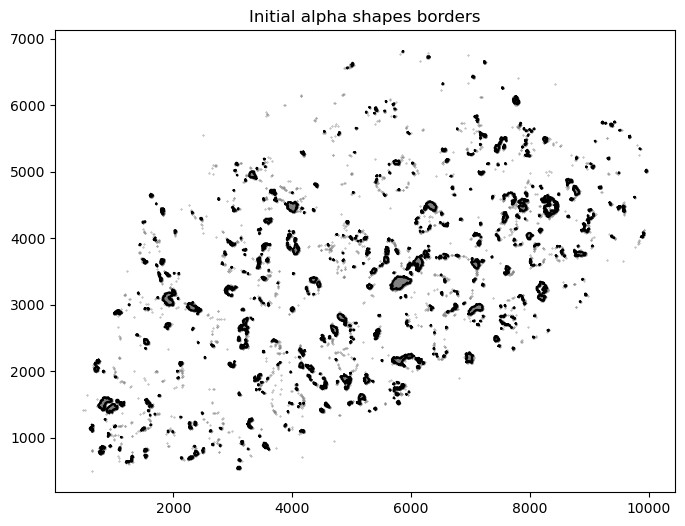

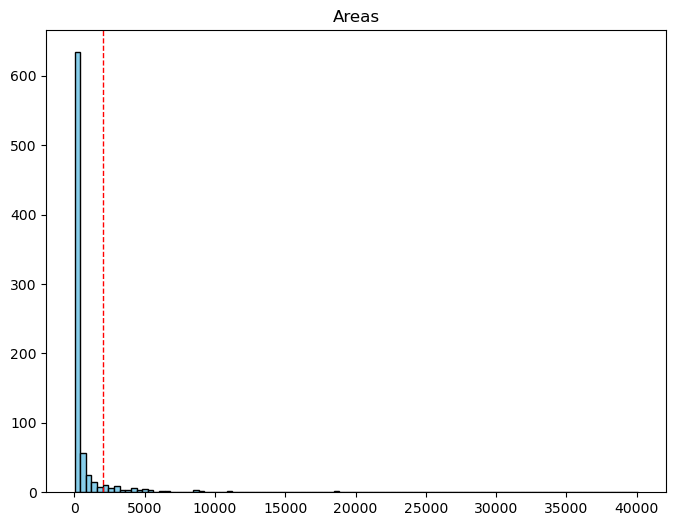

ERROR 1: PROJ: proj_create_from_database: Open of /home/workspace/environment/space2/share/proj failed


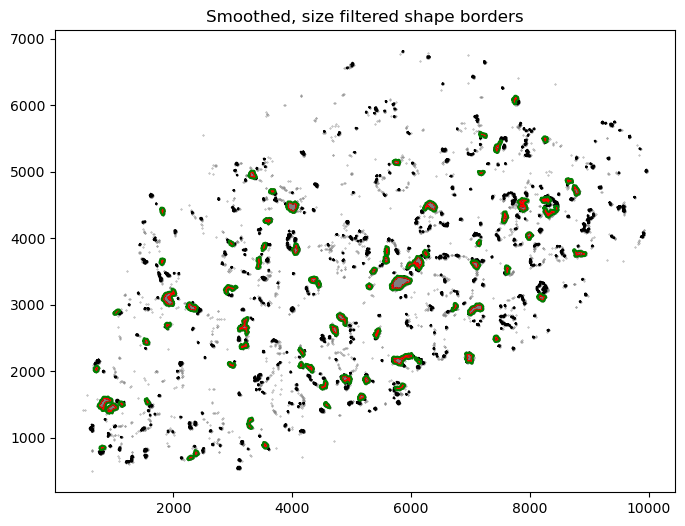

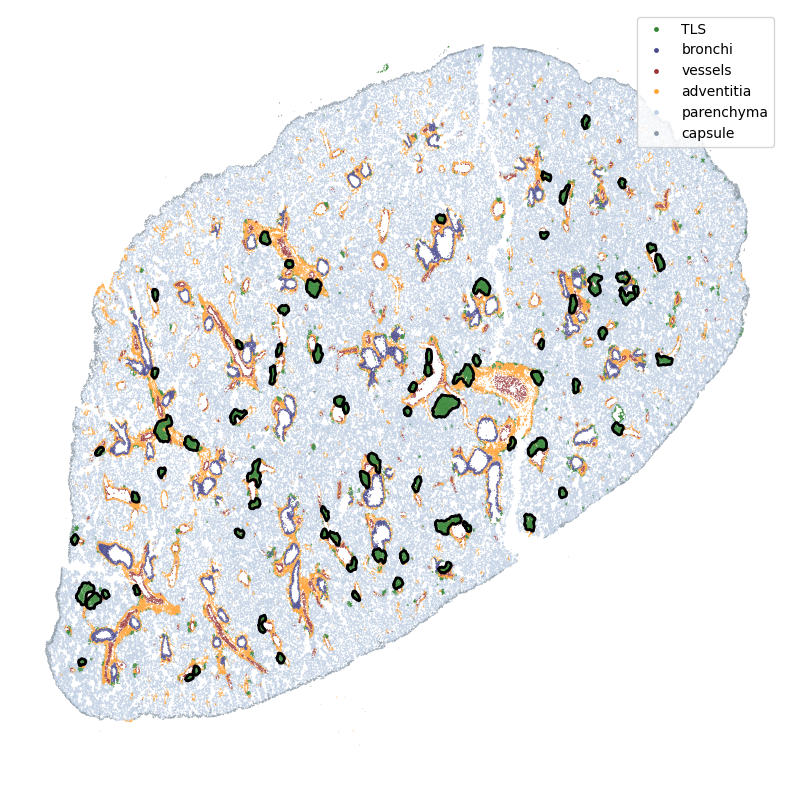

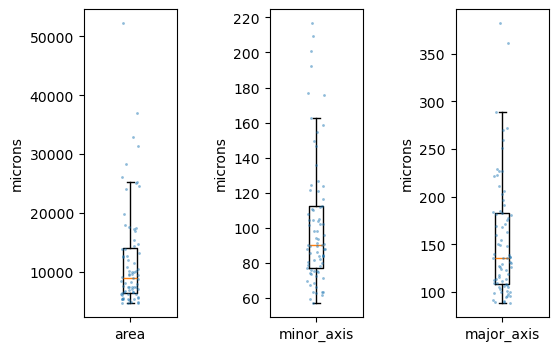

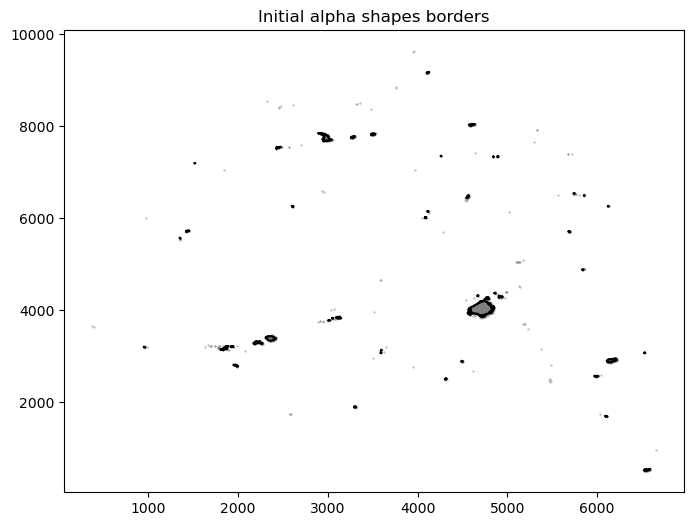

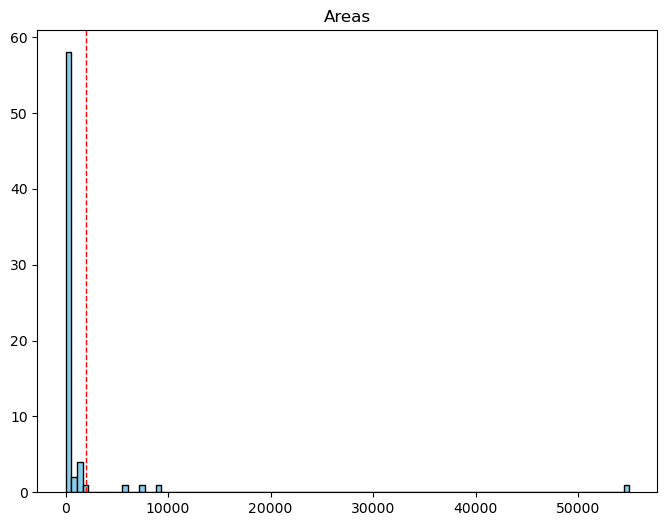

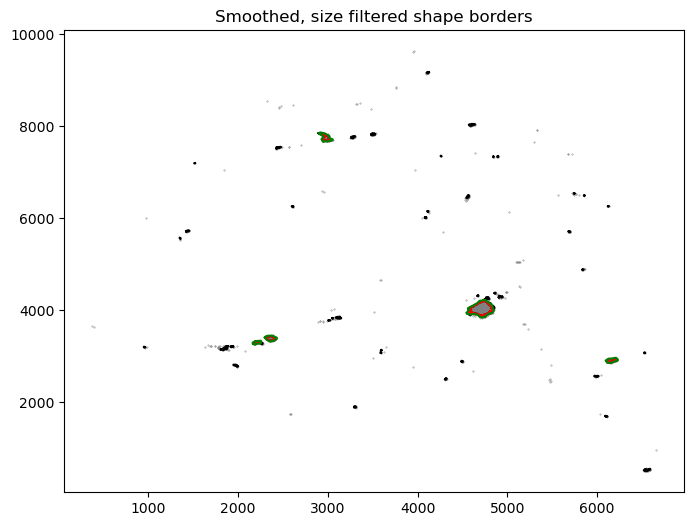

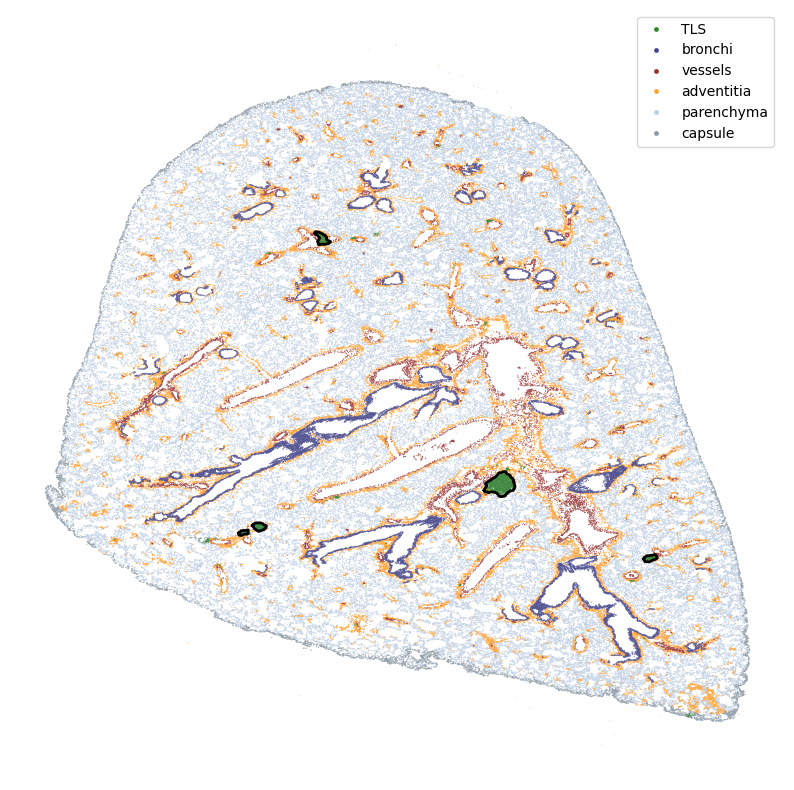

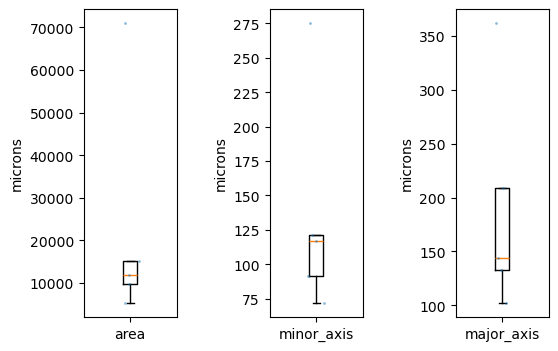

In [15]:
zone_column = 'zone_consol'
zone_id = ['TLS'] 
alpha=0.15
area_threshold = 2000

for sample_label in adata.obs['sample_label'].cat.categories:
    
    adata_sample = adata[adata.obs['sample_label']==sample_label, :]

    # get alphashapes
    alpha_shape = get_alphashape(adata_sample, zone_column, zone_id, alpha)

    if alpha_shape.geoms: # if there are no detected shapes, abort
        
        # process alphashapes
        tls_poly, tls_gdf = process_alphashape(alpha_shape, adata_sample, zone_column, zone_id,area_threshold = area_threshold, circularity_threshold = None)
        
        # plot shape borders in space with zones
        pu.plot_general(adata_sample, x_col='x_centroid', y_col='y_centroid', color_col=zone_column, palette = zone_consol_palette_mapped, alpha = 0.8, colors_sep=False, 
                     save_path = os.path.join(plot_out_dir, sample_label + 'tls_borders_on_cellcharter_all_zone.png'), 
                     poly_list=[tls_poly])
        
        # plot shape metrics
        plot_shape_metrics(tls_gdf, ['area', 'minor_axis', 'major_axis'], 
                           save_path = os.path.join(plot_out_dir, sample_label + 'tls_characteristics.png'))
    
    
        # save poly and gdf for each sample
        joblib.dump(tls_poly, os.path.join(out_dir, 'tls_poly_' + sample_label + '.pkl'))
        tls_gdf.to_file(os.path.join(out_dir, 'tls_gdf_' + sample_label + '.geojson'), driver="GeoJSON")  
    

## Plot structures

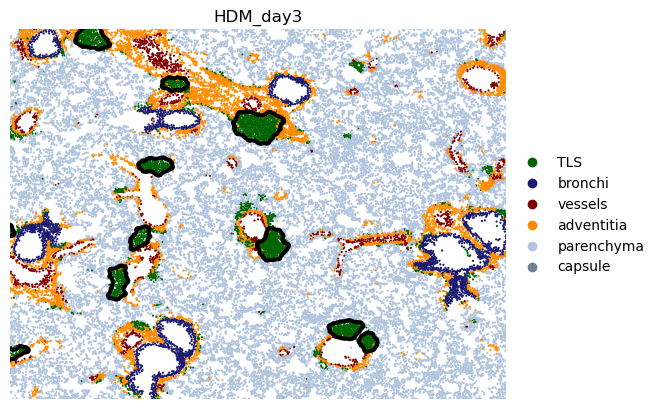

In [17]:
sample_label='HDM_day3'
adata_sample = adata[adata.obs['sample_label']==sample_label, :]
sc.pl.embedding(adata_sample, basis='spatial', color='zone_consol', palette=zone_consol_palette_mapped, title=sample_label, frameon=False, size=10, show=False)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(out_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=3)
    
plt.xlim([3000, 5000])
plt.ylim([3000, 5000])
plt.show()

### Add structure indices to adata.obs for each sample

In [19]:
def add_structure_info_to_adata(adata, structure_gdf, structure_name, sample_label):
    """
    Assign each cell to a spatial structure by point-in-polygon spatial join, and
    save the per-cell structure id/area/centroid to CSV.

    For the given sample's cells (`adata`), a GeoDataFrame of cell-centroid points is
    spatially joined ("within") against `structure_gdf` (the structure polygons). Each
    cell receives the id, area, and centroid of the structure it falls inside (NaN if none).

    Parameters
    ----------
    adata : anndata.AnnData
        AnnData for a single sample, with 'x_centroid'/'y_centroid' in `.obs`.
    structure_gdf : geopandas.GeoDataFrame
        Structure polygons, with 'id', 'area', and 'geometry' columns.
    structure_name : str
        Short name for the structure (e.g. 'tls'), used in the output CSV filename.
    sample_label : str
        Sample identifier, used in the output CSV filename.

    Returns
    -------
    pandas.DataFrame
        Per-cell table (indexed by cell) with columns 'index' (structure id), 'area',
        'centroid_x', and 'centroid_y'. Also written to
        `<out_dir>/<sample_label>_<structure_name>_id_df.csv`.
    """

    index_col = 'index'
    area_col = 'area'

    # add geometry / structure centroid
    structure_gdf['centroid_x'] = structure_gdf['geometry'].centroid.x
    structure_gdf['centroid_y'] = structure_gdf['geometry'].centroid.y
    
    # x y points for each cell 
    points_df = pd.DataFrame(adata.obs[['x_centroid','y_centroid']])
    points_gdf = gpd.GeoDataFrame(points_df, geometry=gpd.points_from_xy(points_df.x_centroid, points_df.y_centroid))
    
    # Perform a spatial join to check if geometries contain any points
    joined_gdf = gpd.sjoin(points_gdf, structure_gdf, how="left", op="within")

    # add ID and area as columns in adata.obs 
    joined_gdf = joined_gdf[~joined_gdf.index.duplicated(keep='first')]
    joined_gdf = joined_gdf.rename(columns={'id': index_col, 'area': area_col})
    joined_gdf[index_col] = joined_gdf[index_col].astype('category')

    # save id / area to csv
    structure_id_df = pd.DataFrame(joined_gdf[[index_col, area_col, 'centroid_x', 'centroid_y']])
    structure_id_df.to_csv(os.path.join(out_dir, sample_label + '_' + structure_name + '_id_df.csv'), index=True)

    return structure_id_df 

In [20]:
for sample_label in adata.obs['sample_label'].cat.categories:
    print(sample_label)

    adata_sample = adata[adata.obs['sample_label']==sample_label, :]

    # Load relevant gdf
    tls_gdf = gpd.read_file(os.path.join(out_dir, 'tls_gdf_' + sample_label + '.geojson'))

    # add to structure info to sample adata 
    tls_id_df = add_structure_info_to_adata(adata_sample, tls_gdf, 'tls', sample_label)

    # update main adata object only for matching indices
    adata.obs.loc[tls_id_df.index, 'tls_index'] = tls_id_df['index'].astype('string')
    adata.obs.loc[tls_id_df.index, ['tls_area', 'tls_centroid_x', 'tls_centroid_y']] = tls_id_df[['area', 'centroid_x', 'centroid_y']].values

HDM_day3
HDM_day30


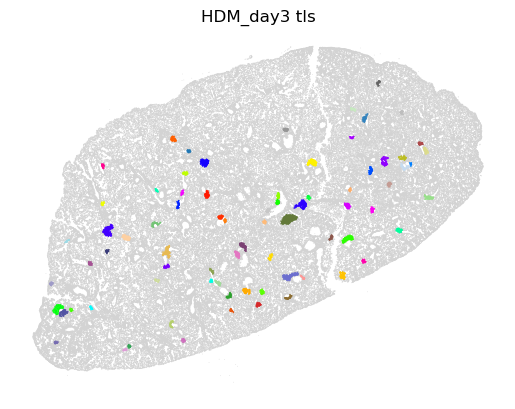

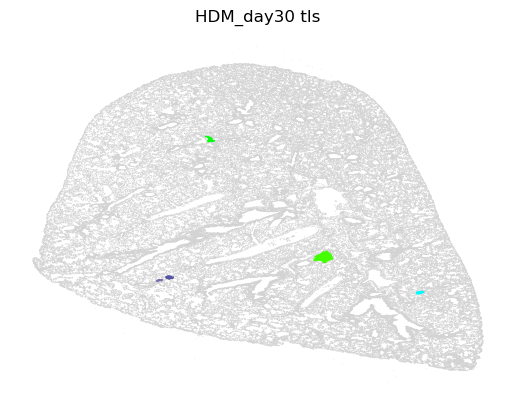

In [21]:
structure_palette = sns.color_palette("tab20", 20) + sns.color_palette("tab20b", 20) + sns.color_palette("tab20c", 20)
structure_palette += sns.color_palette("hsv", 60)
random.shuffle(structure_palette)

for sample_label in adata.obs['sample_label'].cat.categories:
    adata_sample = adata[adata.obs['sample_label']==sample_label, :]
    sc.pl.embedding(adata_sample, basis="spatial", color="tls_index", palette = structure_palette, legend_loc = None, title=sample_label + ' tls', size=1, frameon=False, show=False)

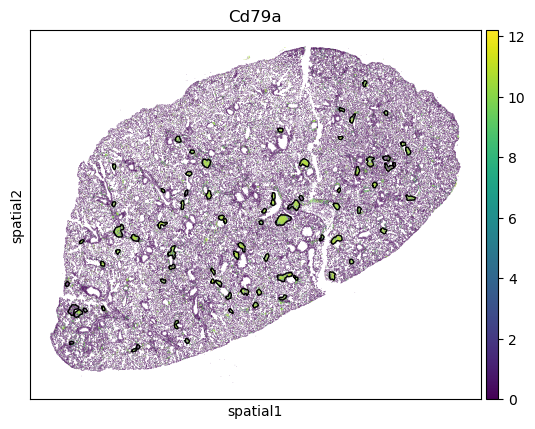

In [22]:
sample_label='HDM_day3'
adata_sample = adata[adata.obs['sample_label']==sample_label, :]
sc.pl.embedding(adata_sample, basis='spatial', color='Cd79a', show=False)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(out_dir, 'tls_poly_' + sample_label + '.pkl'))

for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=1)
plt.show()

In [23]:
adata.write_h5ad(os.path.join(out_dir,'adata_labeled_zones_structures.h5ad'), compression='gzip')


In [24]:
import session_info
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show(excludes=['google3'])

active conda environment:  space2
